# Testing the draft 2D density / contour plot (`new_graphics/density2d.py`)

This notebook exercises `make_density2D()`, the draft implementation of the new 2D
continuous-x-continuous plot type. It is **not** wired into `.plot()` yet — this is
for visually checking the draft before integration.

`make_density2D` renders one underlying KDE density surface two ways, chosen with
`contour=`:
- `contour=False` (default): many fill levels, smooth shading -- the "2D Density Plot" look
- `contour=True`: few fill levels with thin white outlines -- the "Contour Plot" look

**How to run:** open this notebook using the `symbulate` conda environment (kernel
"Python (symbulate)"), then Run All. The setup cell locates the repo root itself (by
walking up from the working directory) so it works regardless of where Jupyter's cwd lands.

**What to look for in every plot:**
- Viridis colormap, dark purple (low density) to yellow (high density)
- Colorbar on the right, labeled "Density" in both modes -- `contour=True` only
  changes the *rendering*, not the underlying statistic
- Quantile-based axis limits (0.1st–99.9th percentile + padding), not raw min/max
- `contour=True` shows thin white outlines between bands; `contour=False` looks smooth

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the repo root (the folder containing symbulate/symbulate.mplstyle) by
# walking up from the working directory, so this notebook runs the same way
# regardless of where Jupyter's cwd lands.
_here = Path.cwd()
REPO_ROOT = next(
    p for p in [_here, *_here.parents]
    if (p / "symbulate" / "symbulate.mplstyle").exists()
)
sys.path.insert(0, str(REPO_ROOT / "team" / "new_graphics"))

# The draft helper and its per-plot-type constants
from density2d import (
    make_density2D,
    DENSITY2D_GRID_POINTS,
    DENSITY2D_SMOOTH_LEVELS,
    DENSITY2D_CONTOUR_LEVELS,
)

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"DENSITY2D_GRID_POINTS = {DENSITY2D_GRID_POINTS}, "
      f"DENSITY2D_SMOOTH_LEVELS = {DENSITY2D_SMOOTH_LEVELS}, "
      f"DENSITY2D_CONTOUR_LEVELS = {DENSITY2D_CONTOUR_LEVELS}")

DENSITY2D_GRID_POINTS = 300, DENSITY2D_SMOOTH_LEVELS = 100, DENSITY2D_CONTOUR_LEVELS = 12


## 1. Reproduce the approved prototypes

Correlated bivariate normal data (x, and y = 0.7x + noise), so the surface is
diagonally elongated like the reference images. Both plots use the *same* simulated
data -- only `contour=` differs.

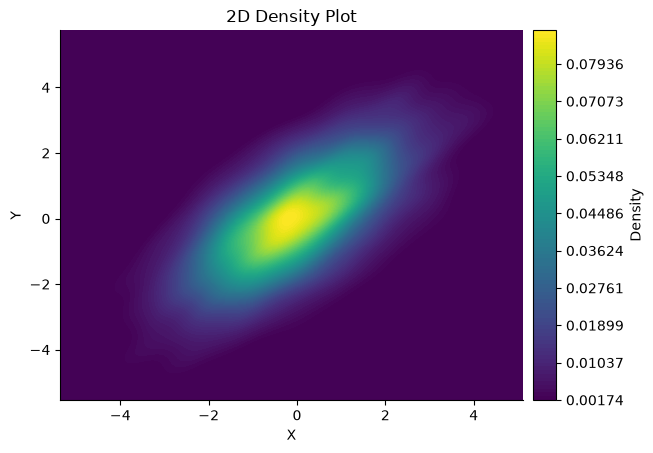

In [2]:
x = rng.normal(0, 1.5, 3000)
y = 0.7 * x + rng.normal(0, 1.2, 3000)

ax = plt.gca()
make_density2D(x, y, ax)  # contour=False (default): smooth "2D Density Plot"
plt.show()

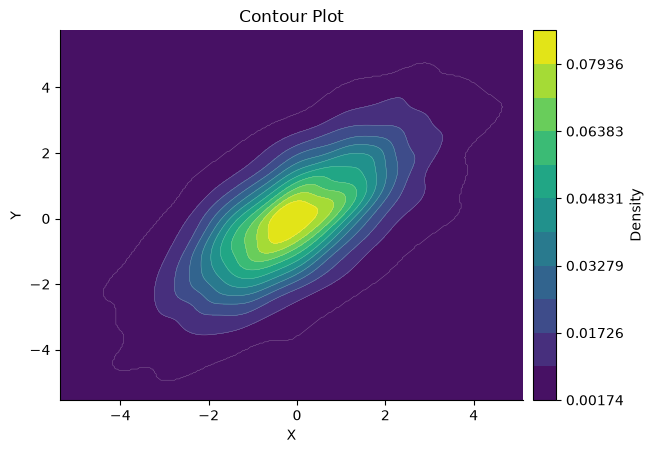

In [3]:
plt.figure()
ax = plt.gca()
make_density2D(x, y, ax, contour=True)  # banded "Contour Plot"
plt.show()

## 2. Reasonable axis limits on outlier-heavy data

Same idea as the 1D density curve: quantile-based bounds instead of raw min/max, so
a heavy-tailed variable (Exponential here, paired with a Normal) doesn't stretch the
plot. The printed comparison shows how much narrower the quantile-based x-range is.

raw x min/max range:     [0.00, 9.65]  (width 9.65)


quantile-based x-range:   [-0.69, 7.62]  (width 8.31)


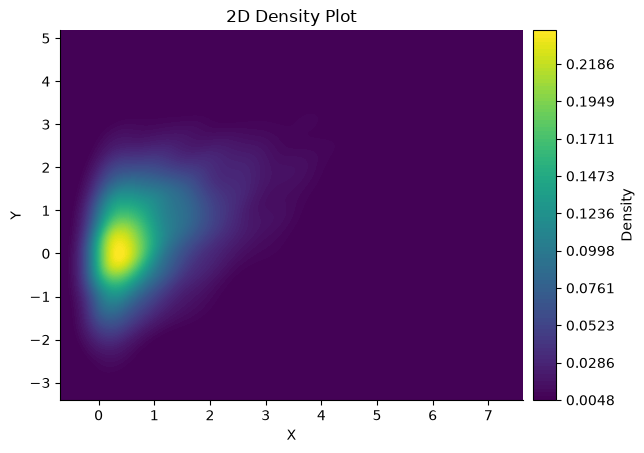

In [4]:
x_exp = rng.exponential(1, 3000)
y_normal = 0.5 * x_exp + rng.normal(0, 1, 3000)

print(f"raw x min/max range:     [{x_exp.min():.2f}, {x_exp.max():.2f}]  "
      f"(width {x_exp.max() - x_exp.min():.2f})")

ax = plt.gca()
make_density2D(x_exp, y_normal, ax)
qxmin, qxmax = ax.get_xlim()
print(f"quantile-based x-range:   [{qxmin:.2f}, {qxmax:.2f}]  (width {qxmax - qxmin:.2f})")
plt.show()

## 3. Overlay behavior — readability warning, not a silent stack

A filled 2D surface can't overlay naturally the way a 1D curve or histogram can: a
second call completely covers the first, and the two color scales compete for the
same colorbar. Rather than silently producing a misleading plot, a second call on the
same axes should print a readability warning below and still draw (matching the
existing warning-category behavior for two 2D tile or two 2D histogram plots).

Showing a second 2D density plot on the same axes. The two color scales compete and this plot now covers up the first one. Try two separate plots (e.g. subplots) instead.


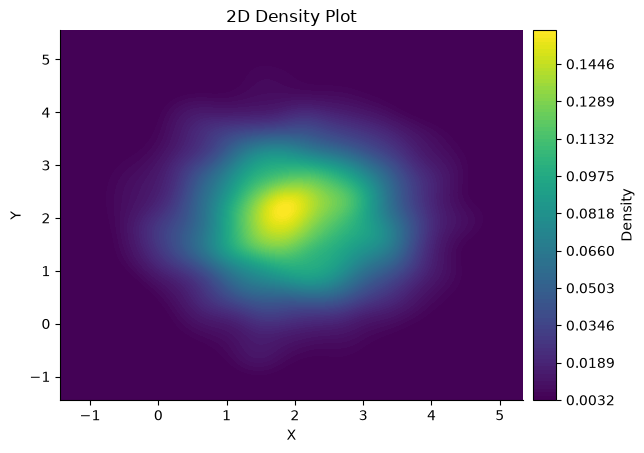

In [5]:
sample_a_x = rng.normal(0, 1, 2000)
sample_a_y = rng.normal(0, 1, 2000)
sample_b_x = rng.normal(2, 1, 2000)
sample_b_y = rng.normal(2, 1, 2000)

ax = plt.gca()
make_density2D(sample_a_x, sample_a_y, ax)
make_density2D(sample_b_x, sample_b_y, ax)  # should print a warning below
plt.show()

## 4. With real symbulate simulation data

Same prototype, but the data comes from an actual `RV(...).sim(...)` call --
`Normal() * Normal()` won't be correlated, so we build correlation with `+`.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

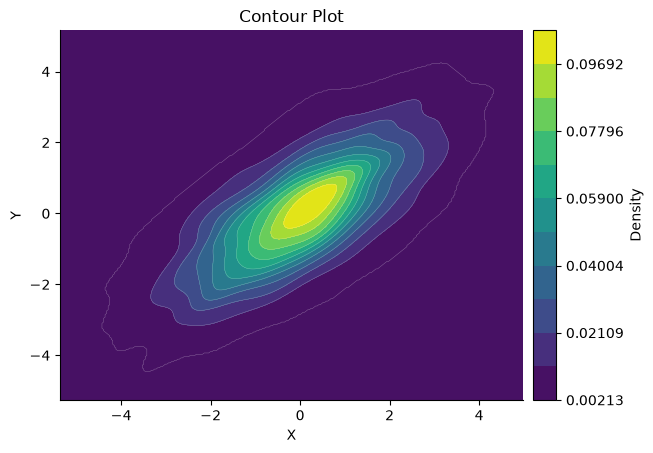

In [6]:
from symbulate import RV, Normal

sims = RV(Normal(0, 1.5) * Normal(0, 1)).sim(3000)  # joint RV: multiply the
# *distributions*, then wrap once in RV(...) -- two separate RV(...) objects
# don't share a probability space and can't be multiplied directly.
arr = np.asarray(sims.results)
sim_x, sim_y = arr[:, 0], 0.7 * arr[:, 0] + arr[:, 1]

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_density2D(sim_x, sim_y, ax, contour=True)
plt.show()

## Verification checklist

- [ ] Section 1's two plots match the approved prototype images
- [ ] `contour=False` looks smooth; `contour=True` shows banded outlines
- [ ] Both modes use viridis and label the colorbar "Density"
- [ ] Colorbar sits on the right via `make_axes_locatable`
- [ ] Quantile-based x-range is visibly narrower than raw min/max on Exponential data
- [ ] A second call on the same axes prints the readability warning and still draws
- [ ] Works on real `.sim()` output, not just numpy arrays